In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
dataDirectory = "../data"
dataRawFileName = "/raw/Churn_Modelling.csv"
dataProcessedFileName = "/processed/churn_processed.csv"

### Initial verifications

In [44]:
df = pd.read_csv(dataDirectory + dataRawFileName)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


- **Tenuere:** Is the time that the customer has been with the company
- **Balance:** Amount of money of the customer
- **Exited:**  Indicates whether a customer has officially left the company or closed their account. (target variable)

In [46]:
# Edit names and drop unnecessary columns
df.rename(columns={"Exited": "Churn"}, inplace=True)
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)

In [47]:
df[["CreditScore", "Age", "Tenure", "NumOfProducts", "EstimatedSalary"]].describe()


,CreditScore,Age,Tenure,NumOfProducts,EstimatedSalary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,1.530200,100090.239881
std,96.653299,10.487806,2.892174,0.581654,57510.492818
min,350.000000,18.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,4.000000,199992.480000


### Encoding categorical variables

In [48]:
df["Gender"].unique()

array(['Female', 'Male'], dtype=object)

In [49]:
gen_map = {"Male": 0, "Female": 1}
df["Gender"] = df["Gender"].map(gen_map)

In [50]:
df["Geography"].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

In [51]:
# one Hot encoding for Geography column, that is, creating new columns for each unique value in the Geography column and assigning 1 or 0 to indicate the presence of that value in each row.
# the choose is because have small number of unique values in the Geography column, so it is better to create new columns for each unique value rather than using label encoding.

df= pd.get_dummies(df, columns=["Geography"], dtype=int, prefix="Country")

In [52]:
df.to_csv(dataDirectory + dataProcessedFileName, index=False)

In [53]:
# Churn rate by categorical features

for col in ["Gender", "NumOfProducts", "IsActiveMember", "HasCrCard"]:
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    display((churn_rate * 100).rename("Churn rate (%)"))

Gender
1    25.071539
0    16.455928
Name: Churn rate (%), dtype: float64

NumOfProducts
4    100.000000
3     82.706767
1     27.714398
2      7.581699
Name: Churn rate (%), dtype: float64

IsActiveMember
0    26.850897
1    14.269074
Name: Churn rate (%), dtype: float64

HasCrCard
0    20.814941
1    20.184266
Name: Churn rate (%), dtype: float64

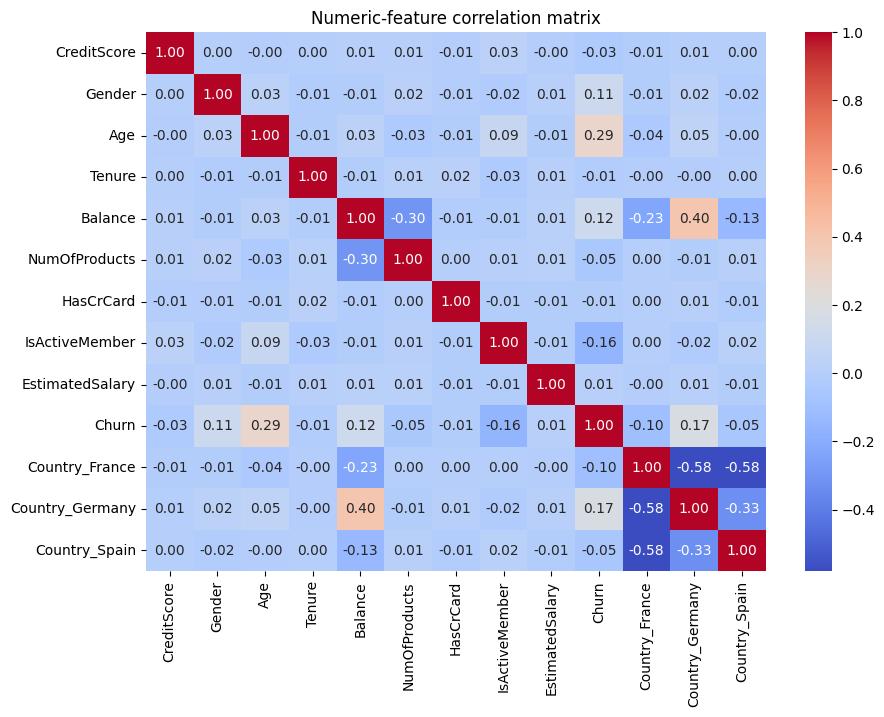

In [54]:
# Correlation between numeric variables

numeric_df = df.select_dtypes(include="number")
plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Numeric-feature correlation matrix")
plt.show()